In [6]:
!pip install sentence-transformers

In [7]:
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket match by 5 wickets",

    # Cooking
    "I prepared pasta using fresh ingredients",
    "The chef cooked a delicious meal",
    "Baking a cake requires precise measurements",

    # Cybersecurity
    "Strong passwords are essential for security",
    "The system was hacked due to vulnerabilities",
    "Encryption protects sensitive data",
    "Firewall prevents unauthorized access"
]

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

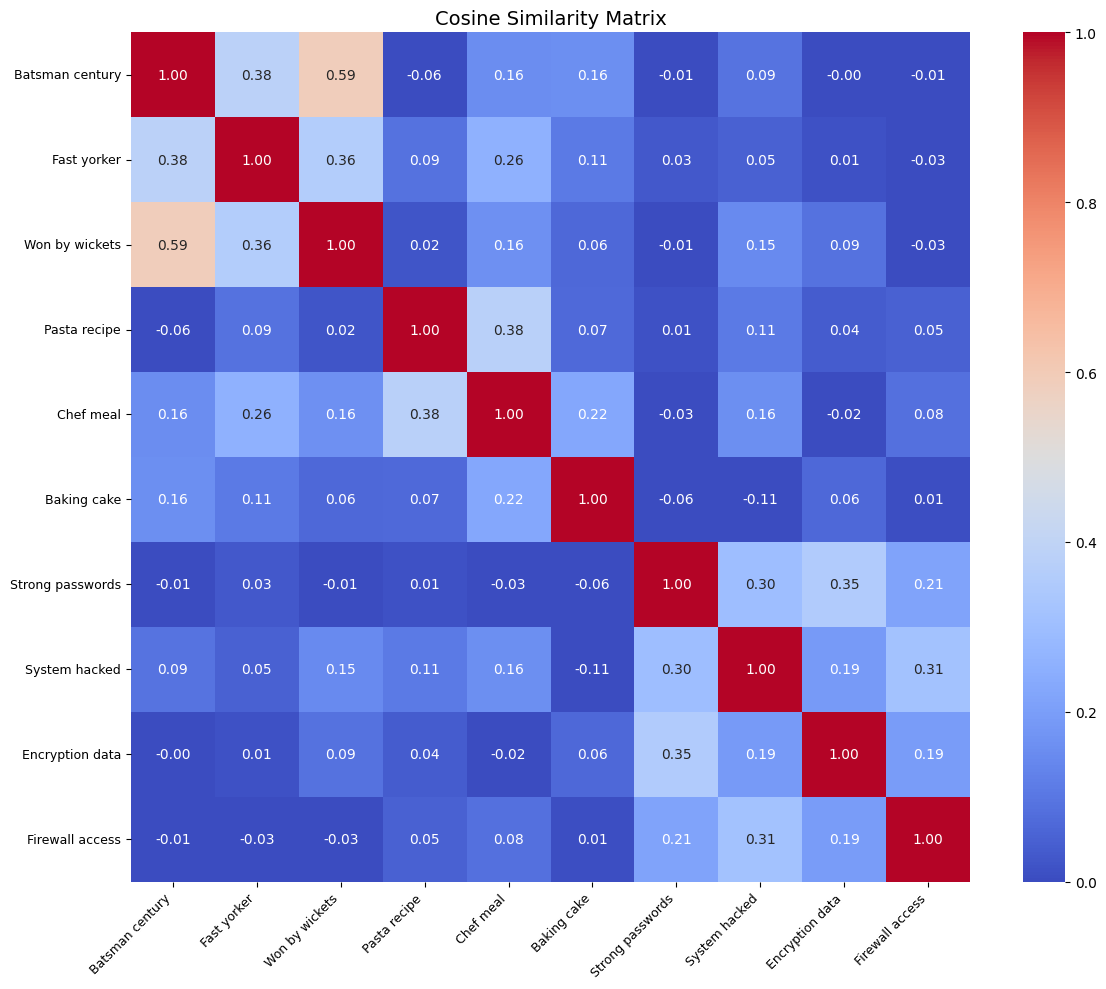

In [4]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

# Short labels for the heatmap axes
labels = [
    "Batsman century",
    "Fast yorker",
    "Won by wickets",
    "Pasta recipe",
    "Chef meal",
    "Baking cake",
    "Strong passwords",
    "System hacked",
    "Encryption data",
    "Firewall access"
]

plt.figure(figsize=(12, 10))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="coolwarm",
    vmin=0,
    vmax=1
)
plt.title("Cosine Similarity Matrix", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print(sentences[idx], "->", similarities[idx])

The team won the cricket match by 5 wickets -> 0.7184911
The batsman scored a century in the match -> 0.5682197


In [8]:
import matplotlib.pyplot as plt
plt.show()